In [2]:
%run ../../../setup_workspace.py # ../ means level u

# Data

In [3]:
def average(Exp, index):
    q, res = Exp.get_1d_data()
    res *= 0
    
    for i in index:
        q, I = Exp.get_1d_data(i)
        res += I
    res /= len(index)
    return q, res

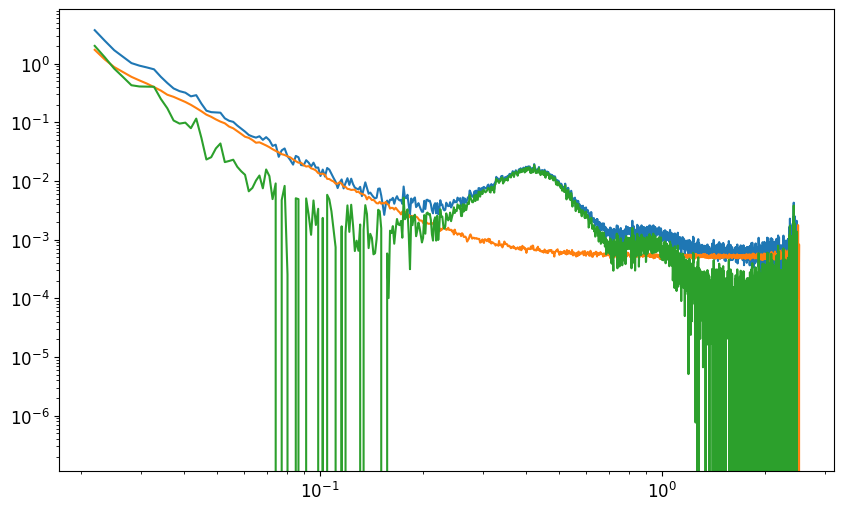

In [4]:

path = r"\\Synology\Data\2025\ESRF_SC5671\ef20\ef20_20250620-091305\ef20_eiger2_00293_00_ave.h5"

Exp_Heat = ID02_experiment(path)
q, I = average(Exp_Heat,[ 20,21,22,23])
plt.loglog(q, I)

path = r'\\Synology\Data\2025\ESRF_SC5671\ef20\ef20_20250620-091305\ef20_eiger2_00034_00_ave.h5'
q, bkg1 = ID02_experiment(path).get_1d_data()

path = r'\\Synology\Data\2025\ESRF_SC5671\ef20\ef20_20250620-091305\ef20_eiger2_00038_00_ave.h5'
q, bkg2 =  ID02_experiment(path).get_1d_data()

path = r'\\Synology\Data\2025\ESRF_SC5671\ef20\ef20_20250620-091305\ef20_eiger2_00037_00_ave.h5'
q, bkg3 =  ID02_experiment(path).get_1d_data()

bkg =( bkg1 + bkg2 + bkg3) / 3
plt.loglog(q, bkg)
q
# plt.loglog(q, I - bkg)
I -= .99657 * bkg
plt.loglog(q, I)

# Analysis

In [41]:
def linear(x,a,b):
    return a * x + b

def sqrt(x): 
    return np.sqrt(x)

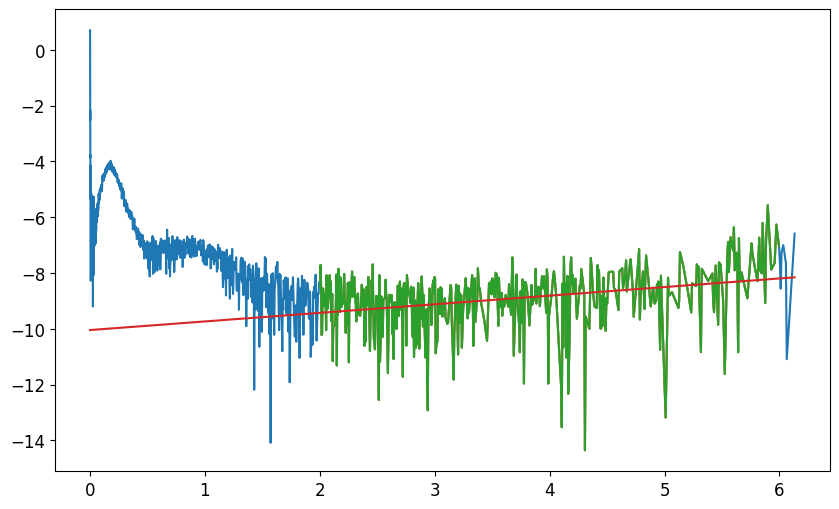

In [7]:
q = q[I>0]
I = I[I>0]
plt.plot(q ** 2, np.log(I))

X = q[(q>sqrt(2))*(q<sqrt(6))] ** 2
Y = np.log(I[(q>sqrt(2))*(q<sqrt(6))])

plt.plot(X, Y)
p, cov = curve_fit(linear, X, Y)
plt.plot(X, Y)
plt.plot(q**2, linear(q**2, *p))

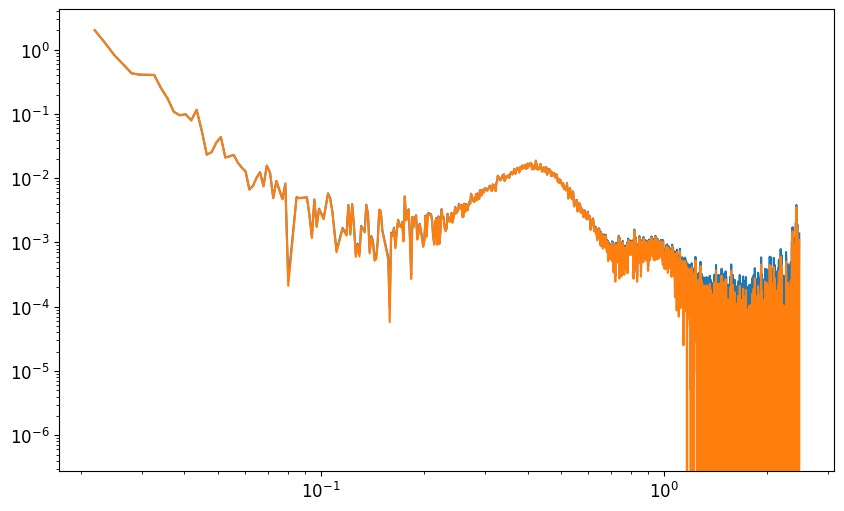

In [8]:
I_Fl = np.exp(p[1]) * np.exp(p[0] * q**2)
I_corr = I - I_Fl

plt.loglog(q, I)
plt.loglog(q, I_corr)

porod

In [9]:
def porod(x, Kp):
    return Kp * x ** -4

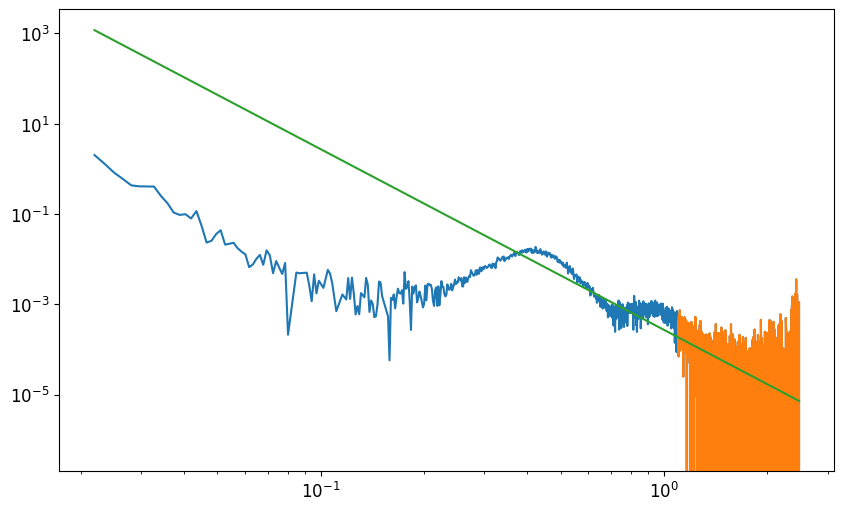

In [37]:
plt.loglog(q, I_corr)

q_min = 1.1
X = q[q>q_min]
Y = I_corr[q>q_min]
plt.plot(X, Y)

Kp, cov = curve_fit(porod, X, Y)
coef = .7
plt.plot(q, coef * porod(q, Kp))

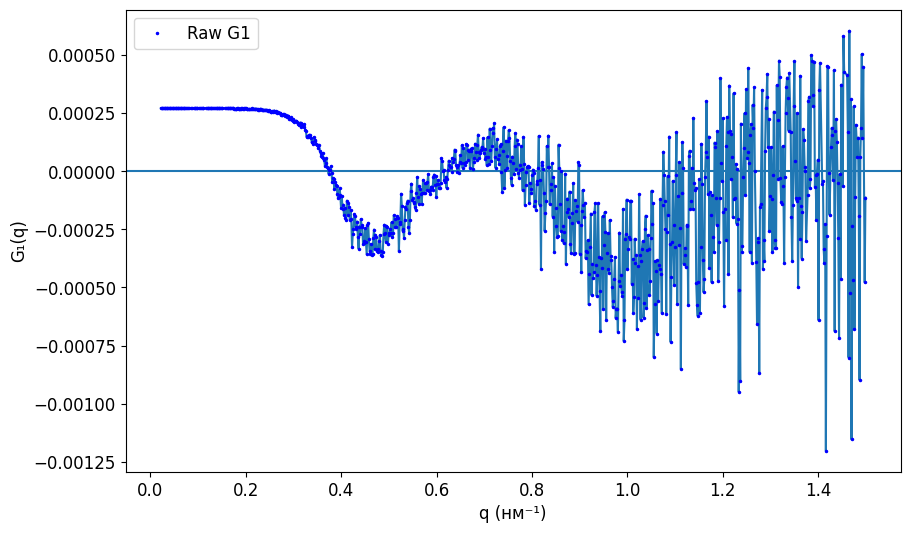

In [38]:
G1 = coef * Kp - I_corr[q<1.5] * q[q<1.5] ** 4
s = q[q<1.5]
plt.plot(s, G1)
plt.axhline(y=0)

from scipy.interpolate import UnivariateSpline

spline = UnivariateSpline(s, G1, s=0.001 * np.var(G1) * len(s))

# Получаем сглаженную G1
G1_smooth = spline(s)

# Визуализация
plt.plot(s, G1, 'b.', label='Raw G1', markersize=3)
# plt.plot(s[s>.45], G1_smooth[s>.45], 'r-', label='Spline-smoothed G1', linewidth=2)
plt.xlabel('q (нм⁻¹)')
plt.ylabel('G₁(q)')
plt.legend()
plt.show()

936
936


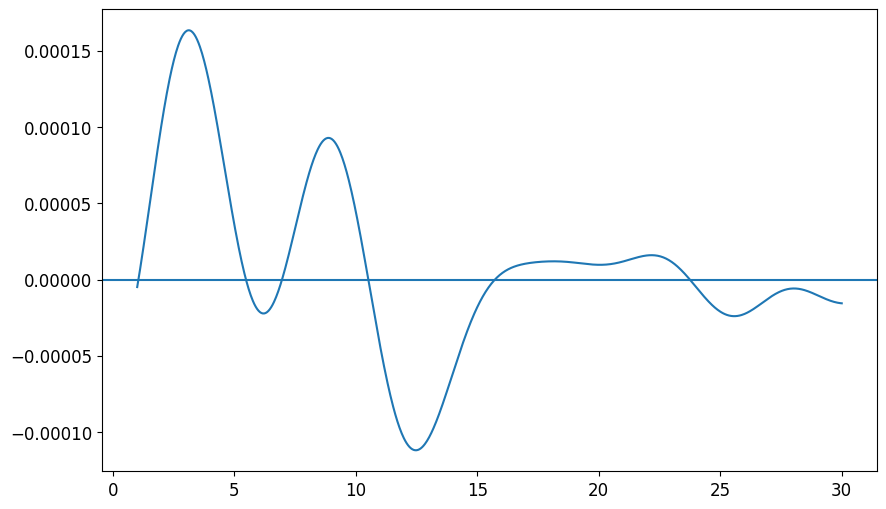

In [40]:
r = np.linspace(1, 30, 1000)
def IDF(x, y, z):
    print(len(x))
    print(len(y))
    return np.trapezoid(y[:, None] * np.cos(x[:, None] * z[None, :]), x, axis=0)

x = s
y = G1_smooth


idf = IDF(x, y, r)
plt.plot(r, idf)

plt.axhline(y=0)

In [81]:
2 *pi / .7

8.975979010256552

# Functions

In [83]:
# ===== GUINIER =====
def guinier(q, A, B):
    return A * np.exp(-B * q**2)

def fit_guinier(q, I, q_range, fixed=None):
    fixed = fixed or {}
    mask = (q >= q_range[0]) & (q <= q_range[1])
    x, y = q[mask], I[mask]
    names = ['A', 'B']
    free = [p for p in names if p not in fixed]
    
    def model(q, *pars):
        vals = dict(fixed)
        for name, val in zip(free, pars):
            vals[name] = val
        return guinier(q, vals['A'], vals['B'])
    
    p0 = [y[0] if name == 'A' else 1.0 for name in free]
    popt, _ = curve_fit(model, x, y, p0=p0)
    
    params = dict(fixed)
    for name, val in zip(free, popt):
        params[name] = val
    return params

# ===== POROD =====
def porod(q, K, sigma, bg):
    return K * q**(-4) * np.exp(-(q * sigma)**2) + bg

def fit_porod(q, I, q_range, fixed=None):
    fixed = fixed or {}
    mask = (q >= q_range[0]) & (q <= q_range[1]) & (q > 0)
    x, y = q[mask], I[mask]
    names = ['K', 'sigma', 'bg']
    free = [p for p in names if p not in fixed]
    
    def model(q, *pars):
        vals = dict(fixed)
        for name, val in zip(free, pars):
            vals[name] = val
        return porod(q, vals['K'], vals['sigma'], vals['bg'])
    
    bg0 = np.min(y)
    K0 = np.median((y - bg0) * x**4)
    p0_dict = {'K': K0, 'sigma': 0.01, 'bg': bg0}
    p0 = [p0_dict[p] for p in free]
    
    popt, _ = curve_fit(model, x, y, p0=p0, bounds=([0]*len(free), [np.inf]*len(free)), maxfev=100000)
    
    params = dict(fixed)
    for name, val in zip(free, popt):
        params[name] = val
    return params

# ===== BUILD CURVE =====
def build_curve(q, I, guinier_range, porod_range, q_max=20, fixed_guinier=None, fixed_porod=None):
    q = np.asarray(q)
    I = np.asarray(I)
    
    # Guinier
    g = fit_guinier(q, I, guinier_range, fixed_guinier)
    q_low = np.linspace(0, np.min(q), 300)
    I_low = guinier(q_low, g['A'], g['B'])
    
    # Porod
    p = fit_porod(q, I, porod_range, fixed_porod)
    
    q_start = porod_range[0]
    q_high = np.linspace(q_start, q_max, 1000)
    I_high = porod(q_high, p['K'], p['sigma'], p['bg'])
    
    mask = q <= q_start
    q_data = q[mask]
    I_data = I[mask]
    
    q_full = np.concatenate([q_low[:-1], q_data, q_high[1:]])
    I_full = np.concatenate([I_low[:-1], I_data, I_high[1:]])

    return q_full, I_full, g, p

# ===== CORRELATION =====
def correlation(q, I, z_max=30, n_z=3000):
    z = np.linspace(0, z_max, n_z)
    Q_star = np.trapezoid(I * q**2, q)
    cos_mat = np.cos(np.outer(z, q))
    Gamma = np.trapezoid(I * q**2 * cos_mat, q, axis=1) / Q_star
    return z, Gamma, Q_star

# ===== IDF =====
def idf(q, I, z_max=30, n_z=3000):
    z = np.linspace(0, z_max, n_z)
    Q_star = np.trapezoid(I * q**2, q)
    cos_mat = np.cos(np.outer(z, q))
    IDF = np.trapezoid(I * q**4 * cos_mat, q, axis=1) / Q_star
    return z, IDF, Q_star

def derivative2(x, y):
    d1 = np.gradient(y, x)
    return np.gradient(d1, x)

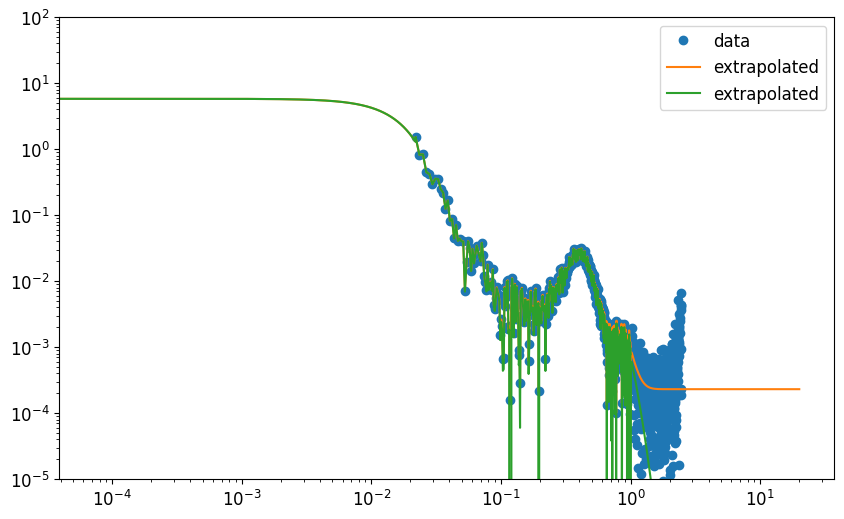

np.float64(1.6529265849029053)

In [84]:
q_full, I_full, g, p = build_curve(
    q[I1>0], I1[I1>0],
    guinier_range=(0.02, 0.3),
    porod_range=(1.0, 1.5),
    q_max=20
)

plt.loglog(q, I1, 'o', label='data')
plt.loglog(q_full, I_full, '-', label='extrapolated')
plt.loglog(q_full, I_full-p['bg'], '-', label='extrapolated')
plt.ylim(1e-5, 1e2)
plt.legend()
plt.show()
p['sigma']

ValueError: when 1d, distances must match the length of the corresponding dimension

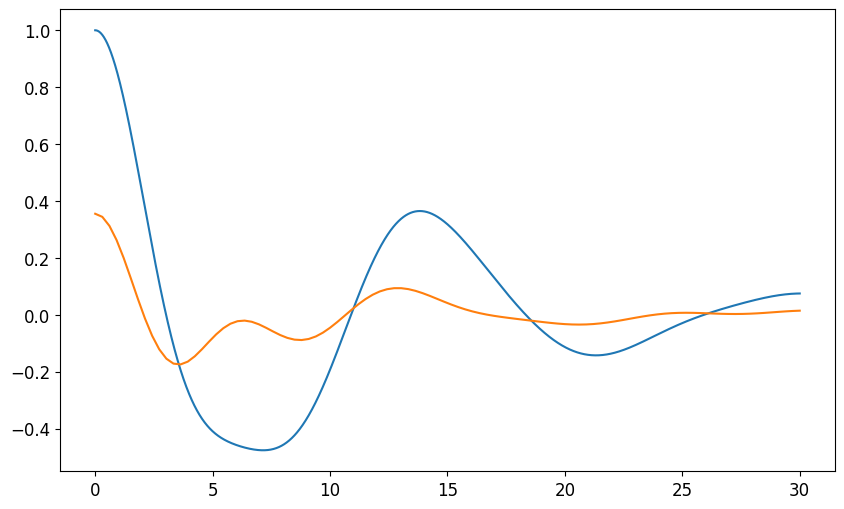

In [85]:
z, Gamma, _ = correlation(q_full, I_full-p['bg'], z_max=30)
plt.plot(z, Gamma)
plt.xlim()

z, IDF, _ = idf(q_full, I_full-p['bg'], z_max=30, n_z=100)
plt.plot(z, IDF)

d2 = derivative2(z, Gamma)
plt.plot(z, d2)
plt.show()